## Perturbation

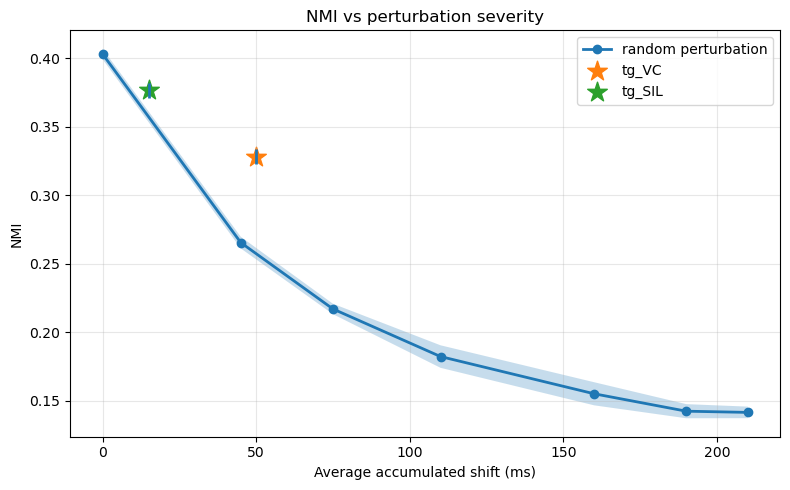

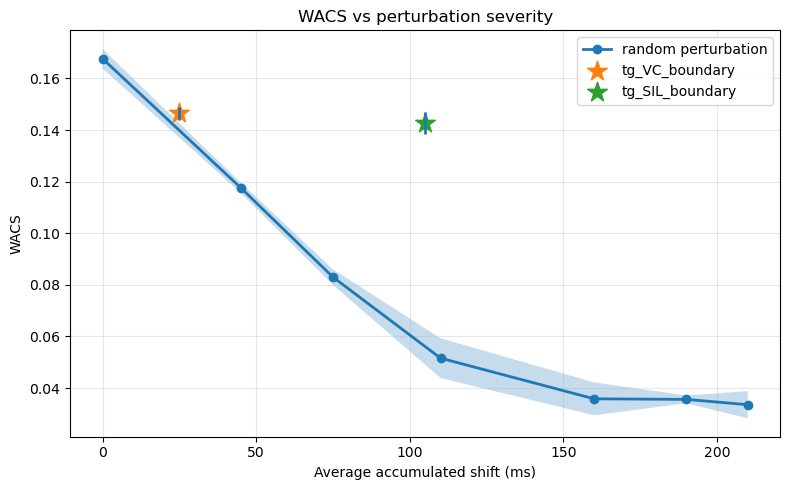

In [20]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
with open("results/perturbation.json") as fp:
    results=json.load(fp)

# ---------------------------------------------------------
# AAS MAP
# ---------------------------------------------------------
aas_map={
    "tg":0,
    "tg_50":45,
    "tg_100":75,
    "tg_200":110,
    "tg_500":160,
    "tg_1000":190,
    "tg_2000":210,
    "tg_VC":50,
    "tg_VC_boundary":25,
    "tg_SIL":15,
    "tg_SIL_boundary":105,
}

line_keys=[
    "tg",
    "tg_50",
    "tg_100",
    "tg_200",
    "tg_500",
    "tg_1000",
    "tg_2000",
]

special_keys=[
    "tg_VC",
    "tg_VC_boundary",
    "tg_SIL",
    "tg_SIL_boundary",
]

# ---------------------------------------------------------
# EXTRACT
# ---------------------------------------------------------
def get_metric_stats(metric_name):

    xs=[]
    means=[]
    stds=[]

    for k in line_keys:

        vals=[
            r[metric_name]["nmi"]
            if metric_name=="nmi"
            else r[metric_name]["wacs"]
            for r in results[k]
        ]

        xs.append(aas_map[k])
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    return (
        np.array(xs),
        np.array(means),
        np.array(stds)
    )

# ---------------------------------------------------------
# PLOT FUNCTION
# ---------------------------------------------------------
def plot_metric(metric_name,ylabel):

    plt.figure(figsize=(8,5))

    # -------------------------------------
    # main perturbation curve
    # -------------------------------------
    xs,means,stds=get_metric_stats(metric_name)

    order=np.argsort(xs)

    xs=xs[order]
    means=means[order]
    stds=stds[order]

    plt.plot(
        xs,
        means,
        marker="o",
        linewidth=2,
        label="random perturbation"
    )

    plt.fill_between(
        xs,
        means-stds,
        means+stds,
        alpha=0.25
    )

    # -------------------------------------
    # VC perturbations
    # -------------------------------------
    for k in special_keys:
        if metric_name == "nmi" and "boundary" in k:
            continue

        if metric_name == "wacs" and "boundary" not in k:
            continue
            
        vals=[
            r[metric_name]["nmi"]
            if metric_name=="nmi"
            else r[metric_name]["wacs"]
            for r in results[k]
        ]

        mean=np.mean(vals)
        std=np.std(vals)

        x=aas_map[k]

        plt.scatter(
            [x],
            [mean],
            marker='*',
            s=220,
            label=k,
        )

        plt.vlines(
            x,
            mean-std,
            mean+std,
            linewidth=2
        )

    # -------------------------------------
    # cosmetics
    # -------------------------------------
    plt.xlabel("Average accumulated shift (ms)")
    plt.ylabel(ylabel)

    plt.title(f"{ylabel} vs perturbation severity")

    plt.grid(True,alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# PLOTS
# ---------------------------------------------------------
plot_metric("nmi","NMI")
plot_metric("wacs","WACS")

## Layer tuning

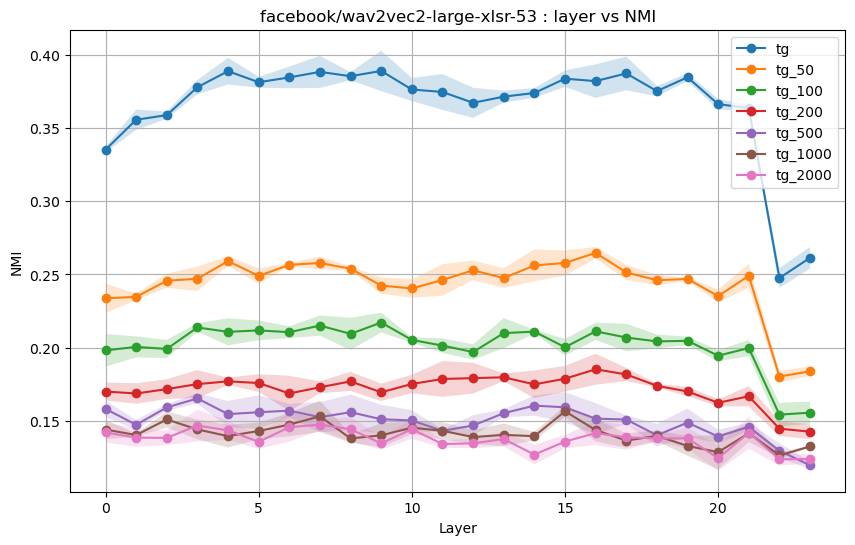

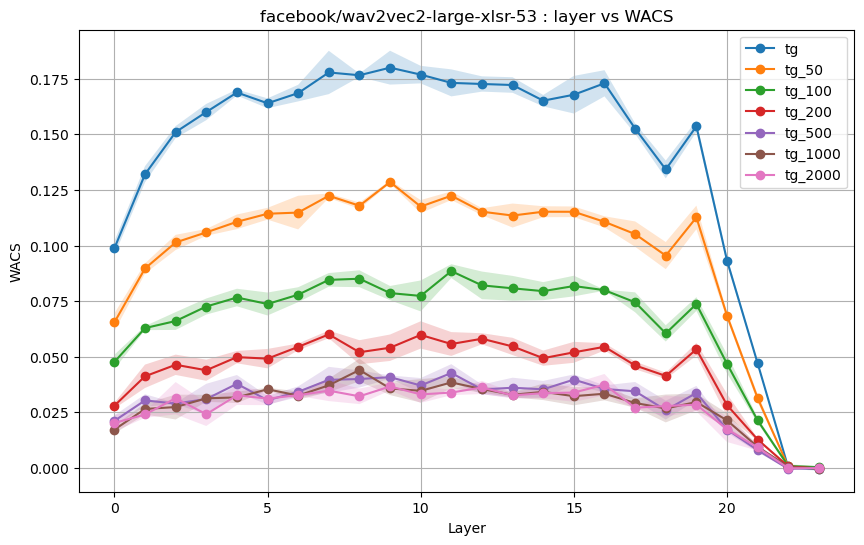

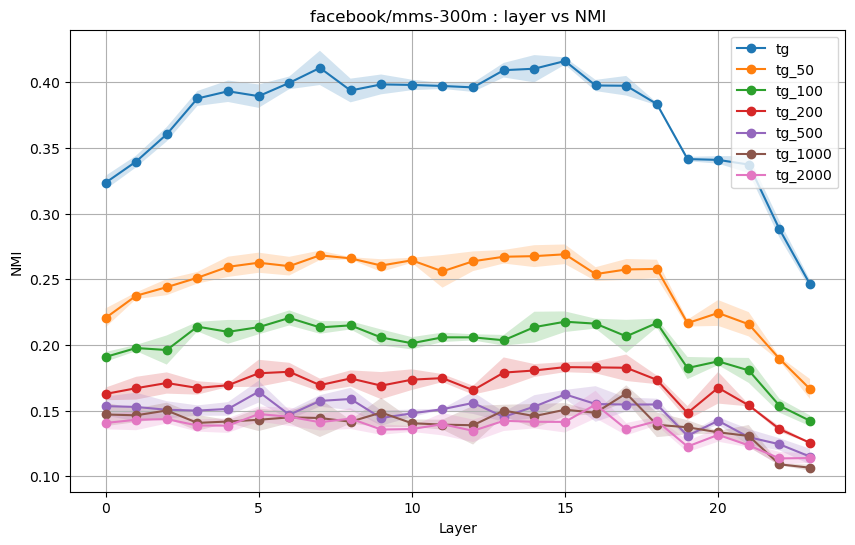

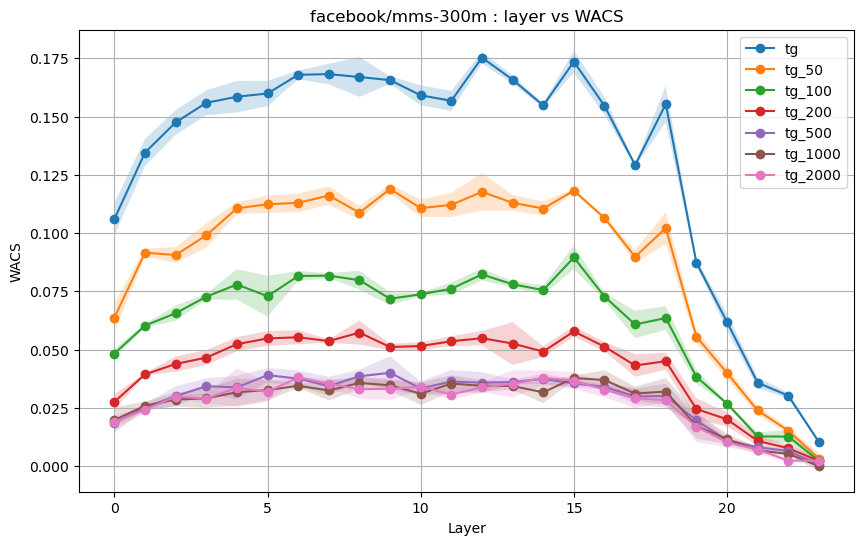

In [2]:
import json, numpy as np, matplotlib.pyplot as plt

with open("results/layer_tuning.json") as fp:
    results=json.load(fp)

tg_order=[
    "tg",
    "tg_50",
    "tg_100",
    "tg_200",
    "tg_500",
    "tg_1000",
    "tg_2000"
]

for model,model_data in results.items():

    layers=sorted(
        [int(k.split("_")[-1]) for k in model_data.keys()]
    )

    # -------------------------
    # NMI
    # -------------------------
    plt.figure(figsize=(10,6))

    for tg_name in tg_order:

        means=[]
        stds=[]

        for layer in layers:

            runs=model_data[f"layer_{layer}"][tg_name]

            vals=[
                r["nmi"]["nmi"]
                for r in runs
                if r["nmi"] is not None
            ]

            if len(vals):
                means.append(np.mean(vals))
                stds.append(np.std(vals))
            else:
                means.append(np.nan)
                stds.append(np.nan)

        means=np.array(means)
        stds=np.array(stds)

        plt.plot(
            layers,
            means,
            marker="o",
            label=tg_name
        )

        plt.fill_between(
            layers,
            means-stds,
            means+stds,
            alpha=0.2
        )

    plt.xlabel("Layer")
    plt.ylabel("NMI")
    plt.title(f"{model} : layer vs NMI")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------
    # WACS
    # -------------------------
    plt.figure(figsize=(10,6))

    for tg_name in tg_order:

        means=[]
        stds=[]

        for layer in layers:

            runs=model_data[f"layer_{layer}"][tg_name]

            vals=[
                r["wacs"]["wacs"]
                for r in runs
                if r["wacs"] is not None
            ]

            if len(vals):
                means.append(np.mean(vals))
                stds.append(np.std(vals))
            else:
                means.append(np.nan)
                stds.append(np.nan)

        means=np.array(means)
        stds=np.array(stds)

        plt.plot(
            layers,
            means,
            marker="o",
            label=tg_name
        )

        plt.fill_between(
            layers,
            means-stds,
            means+stds,
            alpha=0.2
        )

    plt.xlabel("Layer")
    plt.ylabel("WACS")
    plt.title(f"{model} : layer vs WACS")
    plt.legend()
    plt.grid(True)
    plt.show()

## Multilingual Evalution

facebook/mms-300m random NMI 0.09071798316356806 0.016586105809594673
facebook/mms-300m mfa NMI 0.24659800533529191 0.10510582498391513
facebook/mms-300m mms-300m-ipa NMI 0.23893716916753688 0.02779243614324194
facebook/mms-300m w2v2-lv-60-espeak-ipa NMI 0.23709357018411978 0.025185891028626613
facebook/wav2vec2-large-xlsr-53 random NMI 0.09327523888036626 0.015877206495839385
facebook/wav2vec2-large-xlsr-53 mfa NMI 0.23102839461806413 0.09492607498387781
facebook/wav2vec2-large-xlsr-53 mms-300m-ipa NMI 0.22622472733214855 0.025627482269796685
facebook/wav2vec2-large-xlsr-53 w2v2-lv-60-espeak-ipa NMI 0.22493331753723242 0.023415984632047436
facebook/mms-300m random WACS 0.022370569587600808 0.014221026436246701
facebook/mms-300m mfa WACS 0.143394157643965 0.07722348073388516
facebook/mms-300m mms-300m-ipa WACS 0.19495534541612158 0.024974148380713178
facebook/mms-300m w2v2-lv-60-espeak-ipa WACS 0.19309601151490025 0.025858090099243874
facebook/mms-300m qwen3-FA WACS 0.20508045667244393

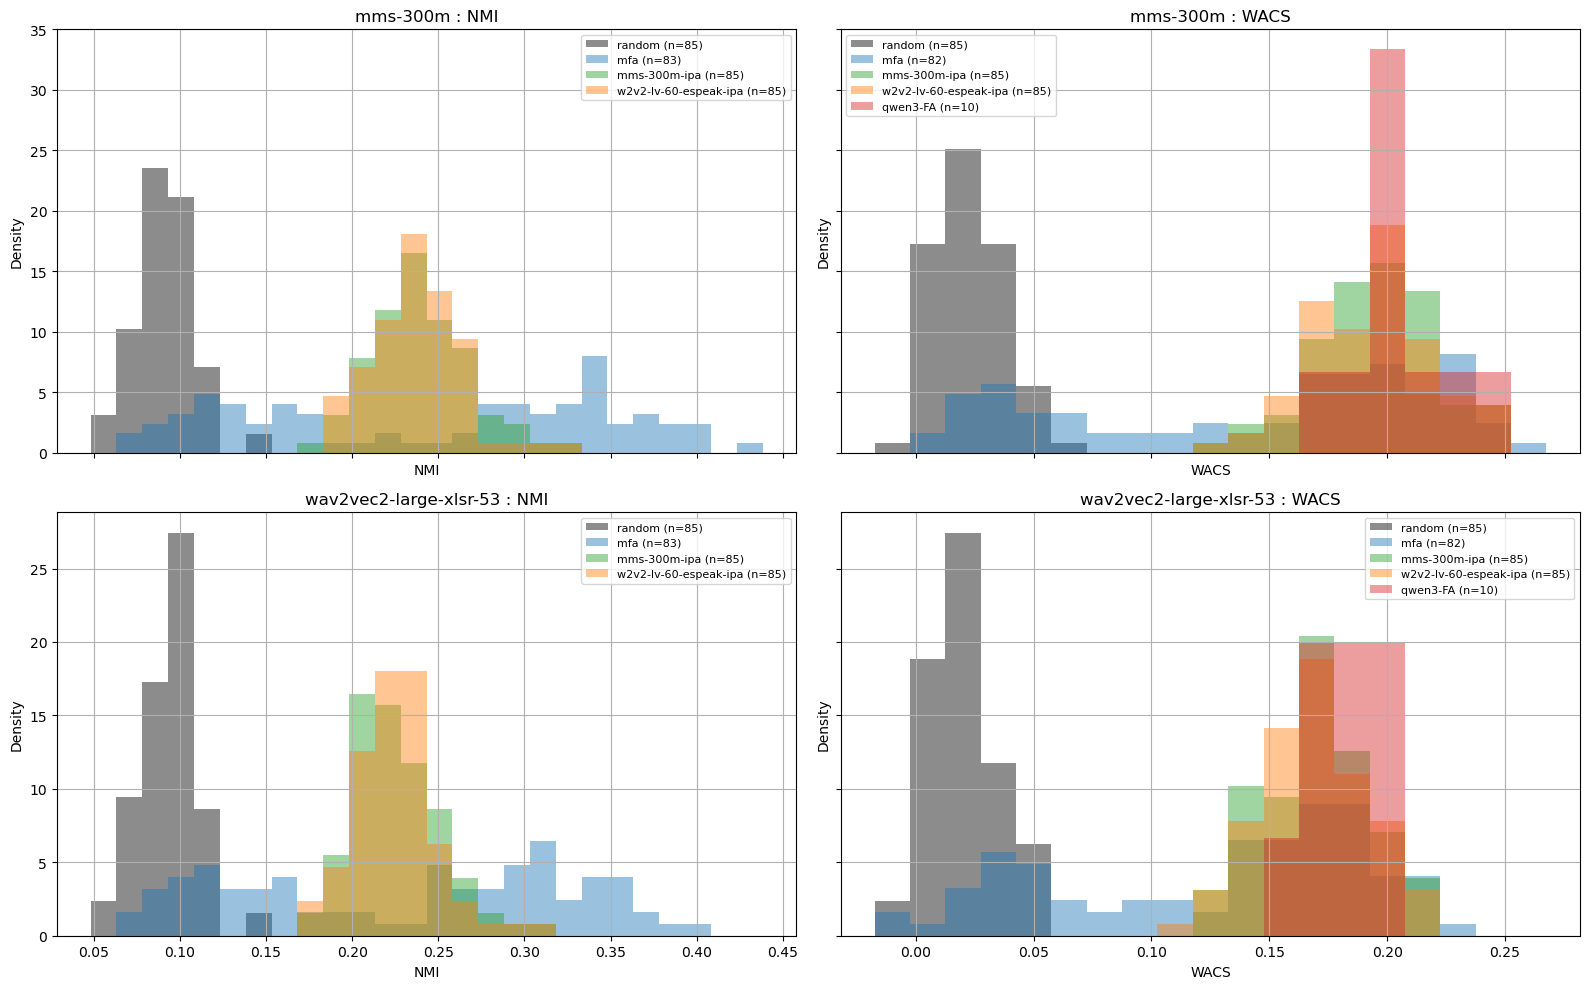

In [8]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS=[
    "random",
    "mfa",
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
    "qwen3-FA",
]

EMB_MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

COLORS={
    "random":"black",
    "mfa":"tab:blue",
    "mms-300m-ipa":"tab:green",
    "w2v2-lv-60-espeak-ipa":"tab:orange",
    "qwen3-FA":"tab:red",
}

BIN_WIDTH=0.015

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results={}

for align_model in ALIGN_MODELS:

    path=os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[align_model]=json.load(fp)

# ---------------------------------------------------------
# COLLECT VALUES
# ---------------------------------------------------------
metrics={
    "nmi":{},
    "wacs":{},
}

for metric in ["nmi","wacs"]:

    for emb_model in EMB_MODELS:

        metrics[metric][emb_model]={}

        for align_model in ALIGN_MODELS:

            vals=[]

            if align_model not in all_results:
                continue

            for lang,lang_data in all_results[align_model].items():

                if emb_model not in lang_data:
                    continue

                x=lang_data[emb_model]

                if x is None or x[metric] is None:
                    continue

                vals.append(
                    x[metric][metric]
                )

            metrics[metric][emb_model][align_model]=vals

# ---------------------------------------------------------
# GLOBAL BINS
# ---------------------------------------------------------
all_nmi=[]
all_wacs=[]

for emb_model in EMB_MODELS:

    for align_model in ALIGN_MODELS:

        all_nmi.extend(
            metrics["nmi"][emb_model].get(align_model,[])
        )

        all_wacs.extend(
            metrics["wacs"][emb_model].get(align_model,[])
        )

nmi_bins=np.arange(
    min(all_nmi),
    max(all_nmi)+BIN_WIDTH,
    BIN_WIDTH
)

wacs_bins=np.arange(
    min(all_wacs),
    max(all_wacs)+BIN_WIDTH,
    BIN_WIDTH
)

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------
fig,axes=plt.subplots(
    2,
    2,
    figsize=(16,10),
    sharex="col",
    sharey="row"
)

# =========================================================
# NMI
# =========================================================
for col,emb_model in enumerate(EMB_MODELS):

    ax=axes[col,0]

    for align_model in ALIGN_MODELS:

        vals=metrics["nmi"][emb_model].get(
            align_model,
            []
        )

        if len(vals)==0:
            continue

        ax.hist(
            vals,
            bins=nmi_bins,
            alpha=0.45,
            density=True,
            color=COLORS[align_model],
            label=f"{align_model} (n={len(vals)})"
        )

        print(
            emb_model,
            align_model,
            "NMI",
            np.mean(vals),
            np.std(vals)
        )

    ax.set_title(
        f"{emb_model.split('/')[-1]} : NMI"
    )

    ax.set_xlabel("NMI")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.legend(fontsize=8)

# =========================================================
# WACS
# =========================================================
for col,emb_model in enumerate(EMB_MODELS):

    ax=axes[col,1]

    for align_model in ALIGN_MODELS:

        vals=metrics["wacs"][emb_model].get(
            align_model,
            []
        )

        if len(vals)==0:
            continue

        ax.hist(
            vals,
            bins=wacs_bins,
            alpha=0.45,
            density=True,
            color=COLORS[align_model],
            label=f"{align_model} (n={len(vals)})"
        )

        print(
            emb_model,
            align_model,
            "WACS",
            np.mean(vals),
            np.std(vals)
        )

    ax.set_title(
        f"{emb_model.split('/')[-1]} : WACS"
    )

    ax.set_xlabel("WACS")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Cluster purities

In [23]:
import os
import json
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS=[
    "random",
    "mfa",
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
    "qwen3-FA",
]

EMB_MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results={}

for align_model in ALIGN_MODELS:

    path=os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if not os.path.exists(path):
        continue

    with open(path) as fp:
        all_results[align_model]=json.load(fp)

# ---------------------------------------------------------
# DISCOVER ALL FIELDS
# ---------------------------------------------------------
all_fields=set()

for align_model,data in all_results.items():

    for lang,lang_data in data.items():

        for emb_model,vals in lang_data.items():

            if vals is None:
                continue

            for section in ["nmi","wacs"]:

                if vals.get(section) is None:
                    continue

                for k in vals[section].keys():
                    all_fields.add((section,k))

all_fields=sorted(all_fields)

# ---------------------------------------------------------
# AGGREGATE
# ---------------------------------------------------------
summary={}

for align_model,data in all_results.items():

    summary[align_model]={}

    for emb_model in EMB_MODELS:

        collected={}

        for section,k in all_fields:
            collected[f"{section}.{k}"]=[]

        for lang,lang_data in data.items():

            if emb_model not in lang_data:
                continue

            vals=lang_data[emb_model]

            if vals is None:
                continue

            for section,k in all_fields:

                if vals.get(section) is None:
                    continue

                v=vals[section].get(k)

                if isinstance(v,(int,float)):
                    collected[f"{section}.{k}"].append(v)

        summary[align_model][emb_model]={}

        for field,xs in collected.items():

            xs=np.array(xs,dtype=np.float64)

            if len(xs)==0:
                continue

            summary[align_model][emb_model][field]={
                "mean":float(np.mean(xs)),
                "std":float(np.std(xs)),
                "min":float(np.min(xs)),
                "max":float(np.max(xs)),
                "n":int(len(xs)),
            }

# ---------------------------------------------------------
# DISPLAY
# ---------------------------------------------------------
for align_model in ALIGN_MODELS:

    if align_model not in summary:
        continue

    print("\n"+"#"*100)
    print(align_model)
    print("#"*100)

    for emb_model in EMB_MODELS:

        if emb_model not in summary[align_model]:
            continue

        print("\n"+"="*80)
        print(emb_model)
        print("="*80)

        rows=[]

        for field,vals in sorted(
            summary[align_model][emb_model].items()
        ):

            rows.append({
                "metric":field,
                "mean":round(vals["mean"],4),
                "std":round(vals["std"],4),
                "min":round(vals["min"],4),
                "max":round(vals["max"],4),
                "n":vals["n"],
            })

        df=pd.DataFrame(rows)

        print(df.to_string(index=False))


####################################################################################################
random
####################################################################################################

facebook/mms-300m
                  metric      mean      std       min       max  n
     nmi.cluster_entropy    3.8337   0.0238    3.7504    3.8753 85
nmi.cluster_entropy_norm    0.9800   0.0061    0.9587    0.9906 85
       nmi.clusters_used   50.0000   0.0000   50.0000   50.0000 85
              nmi.frames 9589.1176 137.9693 9158.0000 9921.0000 85
       nmi.label_entropy    3.5010   0.2064    3.0471    3.9457 85
  nmi.label_entropy_norm    0.8930   0.0238    0.8391    0.9630 85
              nmi.labels   51.6353  11.0292   31.0000   81.0000 85
 nmi.mean_cluster_purity    0.1346   0.0219    0.0832    0.1829 85
                 nmi.nmi    0.0907   0.0166    0.0482    0.1483 85
  nmi.std_cluster_purity    0.1401   0.0415    0.0365    0.2259 85
            wacs.cohen_d    0.2186

In [38]:
# ---------------------------------------------------------
# HEADLINES TABLE
# ---------------------------------------------------------
os.makedirs("results/tables",exist_ok=True)

DISPLAY_NAMES={
    "random":"Baseline",
    "mfa":"MFA",
    "mms-300m-ipa":"MMS-300m-IPA*",
    "w2v2-lv-60-espeak-ipa":"Wav2Vec2-IPA*",
    "qwen3-FA":"Qwen3-FA",
}

FAILURE_RATES={

}
HEADLINE_EMB="facebook/mms-300m"

rows=[]

for align_model in ALIGN_MODELS:

    if align_model not in summary:
        continue

    if HEADLINE_EMB not in summary[align_model]:
        continue

    vals=summary[align_model][HEADLINE_EMB]


    rows.append({
        "Alignment model":
            DISPLAY_NAMES.get(
                align_model,
                align_model
            ),
        "N_Langs":
            f"{vals['wacs.wacs']['n']}",

        "PCMI":
            f"{vals['nmi.nmi']['mean']:.2f} $\\pm$ {vals['nmi.nmi']['std']:.2f}" if "nmi.nmi" in vals else "-",

        "WACS":
            f"{vals['wacs.wacs']['mean']:.2f} "
            f"$\\pm$ "
            f"{vals['wacs.wacs']['std']:.2f}",

    })

headline_df=pd.DataFrame(rows)

print(headline_df.to_string(index=False))

# ---------------------------------------------------------
# LATEX
# ---------------------------------------------------------
latex=[]

latex.append(r"\begin{table}[t]")
latex.append(r"\centering")
latex.append(r"\resizebox{\columnwidth}{!}{%")
latex.append(r"\begin{tabular}{lccc}")
latex.append(r"\toprule")
latex.append(r"\textbf{Alignment model} & \textbf{\#Langs} & \textbf{PCMI} $\uparrow$ & \textbf{WACS} $\uparrow$ \\")
latex.append(r"\midrule")

for _,row in headline_df.iterrows():

    latex.append(
        f"{row['Alignment model']} & "
        f"{row['N_Langs']} &"
        f"{row['PCMI']} & "
        f"{row['WACS']} \\\\"
    )

latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")
latex.append(r"}")

latex.append(
    r"\caption{Multilingual evaluation of forced alignment using PCMI and WACS with MMS-300M speech representations. * - trained in this work.}"
)

latex.append(r"\label{tab:headline_metrics}")
latex.append(r"\end{table}")

latex="\n".join(latex)

out_path="results/tables/headlines.tex"

with open(out_path,"w") as fp:
    fp.write(latex)

print(f"saved {out_path}")

Alignment model N_Langs            PCMI            WACS
       Baseline      85 0.09 $\pm$ 0.02 0.02 $\pm$ 0.01
            MFA      82 0.25 $\pm$ 0.11 0.14 $\pm$ 0.08
  MMS-300m-IPA*      85 0.24 $\pm$ 0.03 0.19 $\pm$ 0.02
  Wav2Vec2-IPA*      85 0.24 $\pm$ 0.03 0.19 $\pm$ 0.03
       Qwen3-FA      10               - 0.21 $\pm$ 0.02
saved results/tables/headlines.tex


## ASR scores

In [14]:
import os
import json
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# MODELS
# ---------------------------------------------------------
MODELS=[
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
]

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
all_results={}

for model in MODELS:

    path=os.path.join(
        "results",
        model,
        "asr.json"
    )

    if not os.path.exists(path):
        print(f"missing {path}")
        continue

    with open(path) as fp:
        all_results[model]=json.load(fp)

# ---------------------------------------------------------
# LANGS
# ---------------------------------------------------------
langs=set()

for model,data in all_results.items():
    langs.update(data.keys())

langs=sorted(langs)

# ---------------------------------------------------------
# BUILD TABLE
# ---------------------------------------------------------
rows=[]

for lang in langs:

    row={"lang":lang}

    
    for met in ['wer', 'cer']:
        for model in MODELS:
            x=all_results.get(model,{}).get(lang)
    
            if x is None:
                row[f"{model}_{met}"]=np.nan
                continue
    
            row[f"{model}_{met}"]=round(
                float(x.get(met,np.nan)),
                4
            )


    rows.append(row)

df=pd.DataFrame(rows)

# ---------------------------------------------------------
# DISPLAY
# ---------------------------------------------------------
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)
pd.set_option("display.width",200)

print(df.to_string(index=False))

       lang  mms-300m-ipa_wer  w2v2-lv-60-espeak-ipa_wer  mms-300m-ipa_cer  w2v2-lv-60-espeak-ipa_cer
      af_za            0.5762                     0.8518            0.1901                     0.3230
      am_et            0.6381                     0.8658            0.1241                     0.2084
      ar_eg            0.5257                     0.9269            0.1408                     0.3082
     ast_es            0.3696                     0.6940            0.0856                     0.1682
      az_az            0.5089                     0.8389            0.1132                     0.2232
      be_by            0.3784                     0.8046            0.0791                     0.1765
      bg_bg            0.3299                     0.7940            0.0766                     0.2066
      bn_in            0.6489                     0.8488            0.1485                     0.2480
      ca_es            0.3395                     0.7109            0.0849        

## ASR - Alignment correlation

In [15]:
import os
import json
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
ALIGN_MODELS=[
    "mms-300m-ipa",
    "w2v2-lv-60-espeak-ipa",
]

EMB_MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53",
]

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------
corr_rows=[]

for align_model in ALIGN_MODELS:

    # -------------------------
    # ASR
    # -------------------------
    asr_path=os.path.join(
        "results",
        align_model,
        "asr.json"
    )

    align_path=os.path.join(
        "results",
        align_model,
        "alignment_results.json"
    )

    if (
        not os.path.exists(asr_path) or
        not os.path.exists(align_path)
    ):
        print(f"missing files for {align_model}")
        continue

    with open(asr_path) as fp:
        asr=json.load(fp)

    with open(align_path) as fp:
        aligns=json.load(fp)

    # -----------------------------------------------------
    # CORRELATIONS
    # -----------------------------------------------------
    for emb_model in EMB_MODELS:

        wers=[]
        cers=[]
        nmis=[]
        wacss=[]

        langs=set(asr.keys()) & set(aligns.keys())

        for lang in langs:

            if emb_model not in aligns[lang]:
                continue

            a=asr[lang]
            m=aligns[lang][emb_model]

            if (
                a is None or
                m is None or
                m["nmi"] is None or
                m["wacs"] is None
            ):
                continue

            wer=a.get("wer")
            cer=a.get("cer")
            nmi=m["nmi"].get("nmi")
            wacs=m["wacs"].get("wacs")

            if None in [wer,cer,nmi,wacs]:
                continue

            wers.append(float(wer))
            cers.append(float(cer))
            nmis.append(float(nmi))
            wacss.append(float(wacs))

        wers=np.array(wers)
        cers=np.array(cers)
        nmis=np.array(nmis)
        wacss=np.array(wacss)

        # -------------------------
        # PEARSON
        # -------------------------
        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"WER vs NMI",
            "pearson_r":pearsonr(wers,nmis)[0],
            "spearman_rho":spearmanr(wers,nmis)[0],
            "n_langs":len(wers),
        })

        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"WER vs WACS",
            "pearson_r":pearsonr(wers,wacss)[0],
            "spearman_rho":spearmanr(wers,wacss)[0],
            "n_langs":len(wers),
        })

        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"CER vs NMI",
            "pearson_r":pearsonr(cers,nmis)[0],
            "spearman_rho":spearmanr(cers,nmis)[0],
            "n_langs":len(cers),
        })

        corr_rows.append({
            "align_model":align_model,
            "emb_model":emb_model.split("/")[-1],
            "metric_pair":"CER vs WACS",
            "pearson_r":pearsonr(cers,wacss)[0],
            "spearman_rho":spearmanr(cers,wacss)[0],
            "n_langs":len(cers),
        })

# ---------------------------------------------------------
# TABLE
# ---------------------------------------------------------
df=pd.DataFrame(corr_rows)

df["pearson_r"]=df["pearson_r"].round(4)
df["spearman_rho"]=df["spearman_rho"].round(4)

print(df.to_string(index=False))


          align_model              emb_model metric_pair  pearson_r  spearman_rho  n_langs
         mms-300m-ipa               mms-300m  WER vs NMI    -0.1608       -0.1373       85
         mms-300m-ipa               mms-300m WER vs WACS    -0.2936       -0.3081       85
         mms-300m-ipa               mms-300m  CER vs NMI    -0.3507       -0.3343       85
         mms-300m-ipa               mms-300m CER vs WACS    -0.5292       -0.5331       85
         mms-300m-ipa wav2vec2-large-xlsr-53  WER vs NMI    -0.0917       -0.0495       85
         mms-300m-ipa wav2vec2-large-xlsr-53 WER vs WACS    -0.3549       -0.3630       85
         mms-300m-ipa wav2vec2-large-xlsr-53  CER vs NMI    -0.2625       -0.2258       85
         mms-300m-ipa wav2vec2-large-xlsr-53 CER vs WACS    -0.5381       -0.5515       85
w2v2-lv-60-espeak-ipa               mms-300m  WER vs NMI    -0.0082       -0.0734       85
w2v2-lv-60-espeak-ipa               mms-300m WER vs WACS    -0.0273       -0.1109       85